##ESCUELA POLITÉCNICA NACIONAL
Facultad de Ingeniería de Sistemas

**Estudiante:** Edwin Daniel Paredes

**Asignatura:** Introducción a los Sistemas de Información

####**Exámen Final Práctico**


###1. Cargar los datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("real_estate_ecuador_200k.csv")
df.head()

,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages
0,Rento Suite 75 metros sector Republica del Sal...,395.66,Pichincha,"Pichincha, Av. Portugal & Av República de El S...",1.0,2.0,65,1.0
1,“Rento departamento en sector la Carolina”,773.69,Pichincha,"Pichincha, Catalina de Aldaz & Av. Portugal, Q...",2.0,2.0,88,1.0
2,Se Renta Amplio Departamento en el Sector de l...,616.94,Pichincha,"Pichincha, Marcos Jofre, Quito, Ecuador",4.0,4.0,214,1.0
3,Hermoso departamento de arriendo de oportunida...,286.69,Pichincha,"Pichincha, De la Prensa Y del Maestro, Quito, ...",2.0,2.0,98,1.0
4,"EN RENTA DEPARTAMENTO, CONJUNTO DIVINO NIÑO",131.54,Pichincha,"Pichincha, Turubamaba, Ecuador",3.0,2.0,53,NaN


In [3]:
df.shape

(200000, 8)

In [5]:
df.describe

<bound method NDFrame.describe of                                                    Titulo  Precio  Provincia  \
0       Rento Suite 75 metros sector Republica del Sal...  395.66  Pichincha   
1              “Rento departamento en sector la Carolina”  773.69  Pichincha   
2       Se Renta Amplio Departamento en el Sector de l...  616.94  Pichincha   
3       Hermoso departamento de arriendo de oportunida...  286.69  Pichincha   
4             EN RENTA DEPARTAMENTO, CONJUNTO DIVINO NIÑO  131.54  Pichincha   
...                                                   ...     ...        ...   
199995                              DEPARTAMENTO EN SAIBA  465.94     Guayas   
199996       Arriendo Departamento 2 Dormitorios, Mañosca  413.17  Pichincha   
199997                   RENTA DEPARTAMENTO PONCIANO ALTO  458.20  Pichincha   
199998  Hermoso departamento de arriendo duplex sector...  380.53  Pichincha   
199999  Hermoso departamento de arriendo sector Poncea...  412.61  Pichincha   

                                                    Lugar  Num. dormitorios  \
0       Pichincha, Av. Portugal & Av República de El S...               1.0   
1       Pichincha, Catalina de Aldaz & Av. Portugal, Q...               2.0   
2                 Pichincha, Marcos Jofre, Quito, Ecuador               4.0   
3       Pichincha, De la Prensa Y del Maestro, Quito, ...               2.0   
4                          Pichincha, Turubamaba, Ecuador               3.0   
...                                                   ...               ...   
199995        Guayas, Ciudadela Saiba, Guayaquil, Ecuador               2.0   
199996  Pichincha, Mañosca & Avenida Occidental, Quito...               3.0   
199997                                         Pichincha,               3.0   
199998           Pichincha, Ponceano Alto, Quito, Ecuador               2.0   
199999           Pichincha, Ponceano Alto, Quito, Ecuador               3.0   

        Num. banos  Area  Num. garages  
0              2.0    65           1.0  
1              2.0    88           1.0  
2              4.0   214           1.0  
3              2.0    98           1.0  
4              2.0    53           NaN  
...            ...   ...           ...  
199995         3.0   104           NaN  
199996         3.0   119           1.0  
199997         2.0   182           1.0  
199998         2.0    86           1.0  
199999         2.0   110           1.0  

[200000 rows x 8 columns]>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Titulo            200000 non-null  object 
 1   Precio            200000 non-null  float64
 2   Provincia         200000 non-null  object 
 3   Lugar             200000 non-null  object 
 4   Num. dormitorios  146845 non-null  float64
 5   Num. banos        165015 non-null  float64
 6   Area              200000 non-null  int64  
 7   Num. garages      142163 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 12.2+ MB


### 2. Limpieza

In [6]:
df.isnull().sum()

,0
Titulo,0
Precio,0
Provincia,0
Lugar,0
Num. dormitorios,53155
Num. banos,34985
Area,0
Num. garages,57837


In [7]:
df['Num. dormitorios'] = df['Num. dormitorios'].fillna(0)
df['Num. banos'] = df['Num. banos'].fillna(0)
df['Num. garages'] = df['Num. garages'].fillna(0)
df.isnull().sum()

,0
Titulo,0
Precio,0
Provincia,0
Lugar,0
Num. dormitorios,0
Num. banos,0
Area,0
Num. garages,0


In [8]:
df = df[df['Precio'] > 0]
df = df[df['Area'] > 0]
df.shape

(200000, 8)

In [9]:
p99_precio = df['Precio'].quantile(0.99)
p99_area = df['Area'].quantile(0.99)
df = df[df['Precio'] < p99_precio]
df = df[df['Area'] < p99_area]
df.shape

(196408, 8)

### 3. Nuevas Columnas: Ciudad, Tipo de Propiedad, Valor por metro cuadrado

In [10]:
def sacar_ciudad(lugar):
    partes = lugar.split(',')
    partes = [p.strip() for p in partes]
    return partes[-2]

df['Ciudad'] = df['Lugar'].apply(sacar_ciudad)
df['Ciudad'].value_counts().head(10)

,count
Ciudad,
Quito,135737
Sangolquí,11423
Pichincha,9209
Guayaquil,7404
Quito 170102,5454
Guayas,2471
Quito 170104,2126
Quito 170134,1780
Babahoyo,1288


In [13]:
def sacar_tipo(titulo):
    t = titulo.upper()
    if 'DEPARTAMENTO' in t or 'DEPTO' in t or 'DPTO' in t:
        return 'Departamento'
    elif 'CASA' in t:
        return 'Casa'
    elif 'SUITE' in t:
        return 'Suite'
    elif 'LOCAL' in t:
        return 'Local Comercial'
    elif 'OFICINA' in t:
        return 'Oficina'
    elif 'BODEGA' in t:
        return 'Bodega'
    elif 'TERRENO' in t:
        return 'Terreno'
    elif 'EDIFICIO' in t:
        return 'Edificio'
    else:
        return 'Otro'

In [14]:
df['Tipo'] = df['Titulo'].apply(sacar_tipo)
df['Tipo'].value_counts()

,count
Tipo,
Departamento,88500
Suite,24640
Oficina,23124
Local Comercial,20857
Casa,20174
Otro,14030
Bodega,4669
Edificio,407
Terreno,7


In [15]:
df['Precio_m2'] = df['Precio'] / df['Area']
df[['Precio','Area','Precio_m2']].head()

,Precio,Area,Precio_m2
0,395.66,65,6.087077
1,773.69,88,8.791932
2,616.94,214,2.882897
3,286.69,98,2.925408
4,131.54,53,2.481887


## **a. Perspectiva Financiera**

i. Precio Promedio de Alquiler (General y por Ciudad)

In [18]:
precio_promedio_general = df['Precio'].mean()
print("Precio promedio de Alquiler (General):", precio_promedio_general)

Precio promedio de Alquiler (General): 673.0253420940084


In [19]:
precio_promedio_ciudad = df.groupby('Ciudad')['Precio'].mean().sort_values(ascending=False)
precio_promedio_ciudad.head(15)

,Precio
Ciudad,
Cotopaxi,3697.685799
Quito 170157,2055.175558
Samborondón,1798.554925
Quito 170132,1128.263136
Ponceano,1021.146284
San Rafael,865.369494
Pifo,853.014755
Guayaquil 090513,813.988978
Quito 170517,749.621243


ii. Costo Promedio por Metro Cuadrado

In [20]:
costo_promedio_m2 = df['Precio_m2'].mean()
print("Costo promedio por m2:", costo_promedio_m2)

Costo promedio por m2: 5.892089417895754


In [24]:
costo_m2_ciudad = df.groupby('Ciudad')['Precio_m2'].mean().sort_values(ascending=False)
costo_m2_ciudad.head(10)

,Precio_m2
Ciudad,
Cotopaxi,36.959531
Guayaquil 090513,10.067906
Samborondón,9.635773
Guayaquil 090511,8.888739
Guayaquil 090512,8.319604
Vía a la Costa,7.786242
Quito 170157,7.476172
Quito 170102,7.077075
Sangolquí,7.057281


iii. Rango de Precios (Min/Max/Media) por Provincia

In [22]:
rango_precios_provincia = df.groupby('Provincia')['Precio'].agg(['min','max','mean'])
rango_precios_provincia

,min,max,mean
Provincia,,,
Cotopaxi,94.47,4557.66,1814.528859
Esmeraldas,111.33,620.53,327.772537
Guayas,130.85,2816.34,614.669888
Imbabura,380.54,589.42,480.809447
Los Rios,176.04,295.08,233.589620
Orellana,118.86,185.84,149.863608
Pichincha,80.21,4685.25,678.455173


### **b. Perspectiva de Producto**

i. Distribución por Tipo de Propiedad: Conteo de registros por Tipo (Casa,
Departamento, Suite, Local Comercial, etc).

In [25]:
conteo_tipo = df['Tipo'].value_counts()
conteo_tipo

,count
Tipo,
Departamento,88500
Suite,24640
Oficina,23124
Local Comercial,20857
Casa,20174
Otro,14030
Bodega,4669
Edificio,407
Terreno,7


ii. Tamaño Promedio de Propiedades: Promedio (Area_m2) por Provincia.

In [26]:
tamano_promedio_provincia = df.groupby('Provincia')['Area'].mean().sort_values(ascending=False)
tamano_promedio_provincia

,Area
Provincia,
Pichincha,144.033064
Imbabura,140.623116
Esmeraldas,110.380597
Guayas,103.337822
Los Rios,88.953416
Cotopaxi,72.428405
Orellana,27.992736


iii. Premium por Habitación Adicional: Diferencia del precio promedio entre
propiedades de 1 habitación vs. 2 habitaciones; 2 habitaciones vs. 3, 3 vs. 4, etc.

In [27]:
precio_por_dormitorio = df.groupby('Num. dormitorios')['Precio'].mean()
precio_por_dormitorio = precio_por_dormitorio[precio_por_dormitorio.index.isin([1,2,3,4,5])]
precio_por_dormitorio

,Precio
Num. dormitorios,
1.0,470.936106
2.0,496.737218
3.0,591.991034
4.0,1073.325486
5.0,1307.772443


In [28]:
premium_habitacion = precio_por_dormitorio.diff()
premium_habitacion

,Precio
Num. dormitorios,
1.0,NaN
2.0,25.801113
3.0,95.253816
4.0,481.334452
5.0,234.446957


## **c. Perspectiva Geográfica**

i. Top 5 Ciudades/Sectores Más Caros: Ranking descendente de Precio Promedio por
ubicación.

In [29]:
top5_caras = df.groupby('Ciudad')['Precio'].mean().sort_values(ascending=False).head(5)
top5_caras

,Precio
Ciudad,
Cotopaxi,3697.685799
Quito 170157,2055.175558
Samborondón,1798.554925
Quito 170132,1128.263136
Ponceano,1021.146284


ii. Concentración de la Oferta: Conteo de propiedades por Provincia o Ciudad.

In [30]:
oferta_provincia = df['Provincia'].value_counts()
oferta_provincia

,count
Provincia,
Pichincha,178686
Guayas,13960
Los Rios,1288
Cotopaxi,859
Esmeraldas,804
Orellana,413
Imbabura,398


In [31]:
oferta_ciudad = df['Ciudad'].value_counts().head(10)
oferta_ciudad

,count
Ciudad,
Quito,135737
Sangolquí,11423
Pichincha,9209
Guayaquil,7404
Quito 170102,5454
Guayas,2471
Quito 170104,2126
Quito 170134,1780
Babahoyo,1288


## **d. Segmentación de Mercado**

i. Crear una nueva columna: Tipo de Inmueble.


In [33]:
Q1 = df['Precio'].quantile(0.25)
Q3 = df['Precio'].quantile(0.75)
print(Q1, Q3)

372.63 717.77


In [34]:
def segmentar(precio):
    if precio < Q1:
        return 'Economico'
    elif precio > Q3:
        return 'Lujo'
    else:
        return 'Medio'

df['Tipo de Inmueble'] = df['Precio'].apply(segmentar)
df['Tipo de Inmueble'].value_counts()

,count
Tipo de Inmueble,
Medio,98206
Lujo,49101
Economico,49101


## **e. Dashboard**

i. Total de propiedades

In [41]:
total_propiedades = len(df)
print("Total de propiedades:", total_propiedades)

Total de propiedades: 196408


ii. Gráfico de barras de Precio promedio de alquiler (General y por Ciudad)


In [44]:
top10_ciudades = precio_promedio_ciudad.head(10)
display(top10_ciudades)

,Precio
Ciudad,
Cotopaxi,3697.685799
Quito 170157,2055.175558
Samborondón,1798.554925
Quito 170132,1128.263136
Ponceano,1021.146284
San Rafael,865.369494
Pifo,853.014755
Guayaquil 090513,813.988978
Quito 170517,749.621243


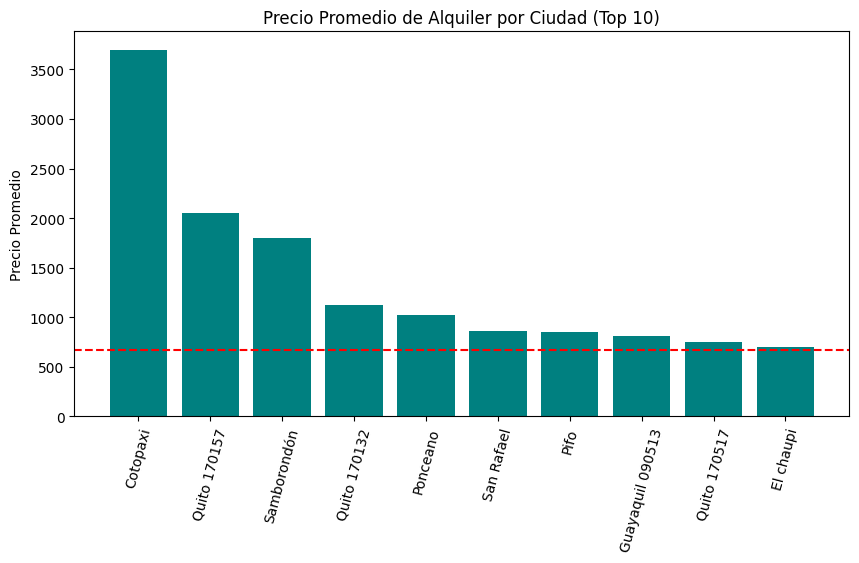

In [55]:
plt.figure(figsize=(10,5))
plt.bar(top10_ciudades.index, top10_ciudades.values, color='Teal')
plt.axhline(precio_promedio_general, color='red', linestyle='--')
plt.xticks(rotation=75)
plt.ylabel('Precio Promedio')
plt.title('Precio Promedio de Alquiler por Ciudad (Top 10)')
plt.show()

iii. Gráfico de dispersión de la relación entre Área y Precio


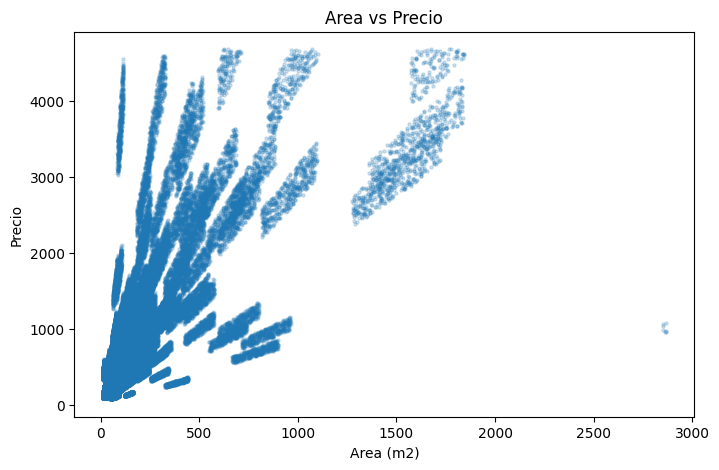

In [48]:
plt.figure(figsize=(8,5))
plt.scatter(df['Area'], df['Precio'], alpha=0.2, s=5)
plt.xlabel('Area (m2)')
plt.ylabel('Precio')
plt.title('Area vs Precio')
plt.show()

iv. Gráfico de pastel de conteo de registros por Tipo (Casa, Departamento, Suite, Local
Comercial).

In [ ]:
plt.figure(figsize=(7,7))
plt.pie(conteo_tipo.values, labels=conteo_tipo.index, autopct='%1.1f%%')
plt.title('Distribucion por Tipo de Propiedad')
plt.show()

v. Gráfico de Premium por Habitación Adicional

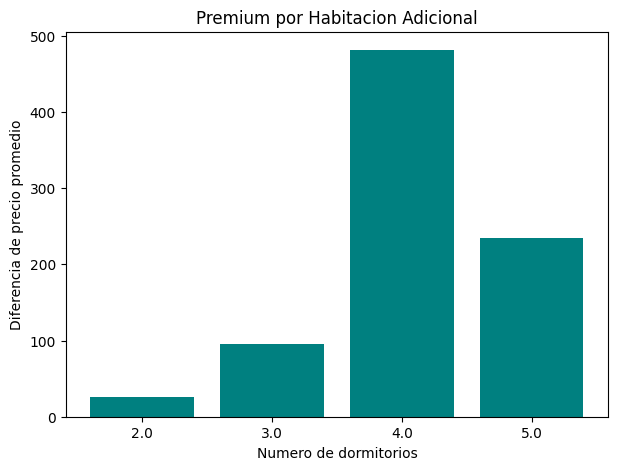

In [56]:
plt.figure(figsize=(7,5))
plt.bar(premium_habitacion.index.astype(str), premium_habitacion.values, color='Teal')
plt.xlabel('Numero de dormitorios')
plt.ylabel('Diferencia de precio promedio')
plt.title('Premium por Habitacion Adicional')
plt.show()